# Data Analytics - Exercise 7

Note that the tasks should be submitted as an HTML file, showing both the contents of the code cells and the outputs. You can get the notebook as an HTML file by selecting File -> Download as -> HTML. The answers to the tasks can be done in one or more code cells.

**Student Name**: Jayani Kothalawala

**Student Number**: AD9680

## Formatting Plots

Visualization is one of the most effective ways to make observations from data. For the readability of graphs and charts, it is important to include a title and axis labels. Sometimes it may also be appropriate to set a background grid and adjust the spacing of axis ticks.

Below is the code for creating a plot (using np arrays). Make the plot detailed according to the model below. Check the [matplotlib specs](https://matplotlib.org/3.5.3/api/_as_gen/matplotlib.pyplot.html) to see how to format the parts of the plot. You can leave the thickness of the axes and other lines in the plot at the default settings. The colors used in the grid, line, and curves are 'blue', 'red', 'black', and 'green'. If you cannot distinguish the colors, it does not matter if the colors are "mixed up."

![malli2](https://student.labranet.jamk.fi/~ajota/Data-analytics/images/malli_kuvaajien_muotoilut.png)

Scoring: 1.5 p

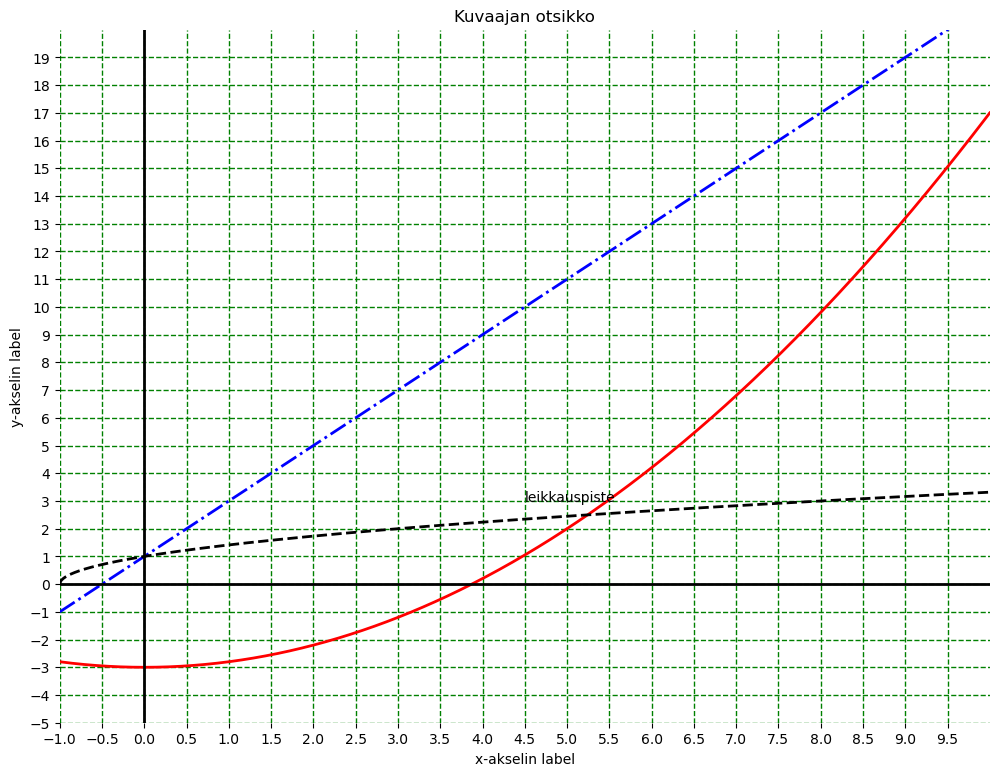

In [150]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(-1,10,1000)
y1 =  2*x +1
y2 = 0.2*x**2-3
y3 = (x+1)**0.5

# Filout the formations to the code below.
fig, ax = plt.subplots(figsize=(12, 9))
# Plot lines with styles
ax.plot(x, y1, linestyle="dashdot", linewidth=2, color="blue")   # blue dashed
ax.plot(x, y2, linewidth=2, color="red")                   # red
ax.plot(x, y3, linestyle="--", linewidth=2, color="black")   # black dashed
ax.axhline(0, linewidth=2, color="black")
ax.axvline(0, linewidth=2, color="black")



ax.set_title("Kuvaajan otsikko")
ax.set_xlabel("x-akselin label")
ax.set_ylabel("y-akselin label")

ax.set_xlim(-1, 10)
ax.set_ylim(-5, 20)


ax.text(4.5, 3, "leikkauspiste")

ax.set_xticks(np.arange(-1, 10.0, 0.5))  
ax.set_yticks(np.arange(-5, 20, 1))  
ax.grid(linestyle="--",color="green", linewidth=1)

plt.show()

## Source Countrien in a Horizontal Bar Chart

Read the data from 'https://student.labranet.jamk.fi/~ajota/Datasets/cybersecurity_attacks_2022_2023.csv' and visualize the number of connections in a horizontal bar chart according to the source country part ('Source IP Continent'). The same could be done, for example, for IP addresses and other information over a certain period, where visualizing the data might reveal something suspicious and warrant further investigation. For now, let's focus on practicing visualization and see where the connections are coming from.

Note! The number of connections should match the numbers in the model below. The colors or the order of the bars do not need to be the same as in the model. If you wish, you can also set a Finnish label for the x-axis and a title for the chart.

![malli](https://student.labranet.jamk.fi/~ajota/Data-analytics/images/malli_vaakapylvaskaavio_sourceIPcontinent.png)

Scoring: 0.5 p

In [151]:
import pandas as pd
import seaborn as sns

C:\Users\jayan\AppData\Local\Temp\ipykernel_9680\419214154.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


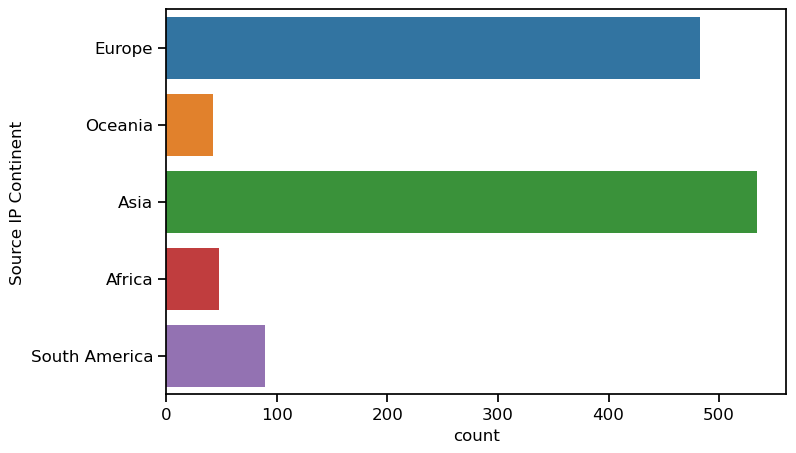

In [192]:
# Data to be used in the chart:
df = pd.read_csv('https://student.labranet.jamk.fi/~ajota/Datasets/cybersecurity_attacks_2022_2023.csv', index_col=0)


df = df.dropna(subset=["Source IP Continent"])
df["Source IP Continent"]
count = df.groupby(["Source IP Continent"]).size()
order = ["Europe", "Oceania", "Asia", "Africa", "South America"]
# Write the code below.
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    x=count.values,   # Since count is a Series
    y=count.index,
    orient="h",
    palette="tab10",
    order=order,
    ax=ax
)

# Reduce font sizes
ax.set_xlabel("count", fontsize=12)     # x-axis label
ax.set_ylabel("Source IP Continent", fontsize=12) # y-axis label
ax.tick_params(axis='x', labelsize=12)  # x-axis tick labels
ax.tick_params(axis='y', labelsize=12)  # y-axis tick labels


ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)

plt.show()




## Visualizing change

Let's continue with the data from the previous task. Sometimes, when examining data, it is useful to compare it to a previous time period. This can provide clues about possible changes or what is "normal." What was the situation like before, and have there been any changes compared to the present? Is it normal for there to be traffic at time X or for traffic to come from country Y? Visualization is also an effective tool for comparison. Depending on the situation, you can try comparing on a yearly, monthly, daily, or hourly basis. If there are many items to compare, a line chart might be a more illustrative option.

Create a bar chart that visualizes the traffic volumes from different European countries ('Source IP Continent') on an annual basis according to the model below. Note that some of the information you need to draw the bar chart may be missing from the data -> create new columns in the dataframe as needed to complete the chart. Also, pay attention to the formatting of the chart!

![malli2](https://student.labranet.jamk.fi/~ajota/Data-analytics/images/malli_pylvaskaavio_sourceIPcontinentEurope.png)

Scoring: 1 p

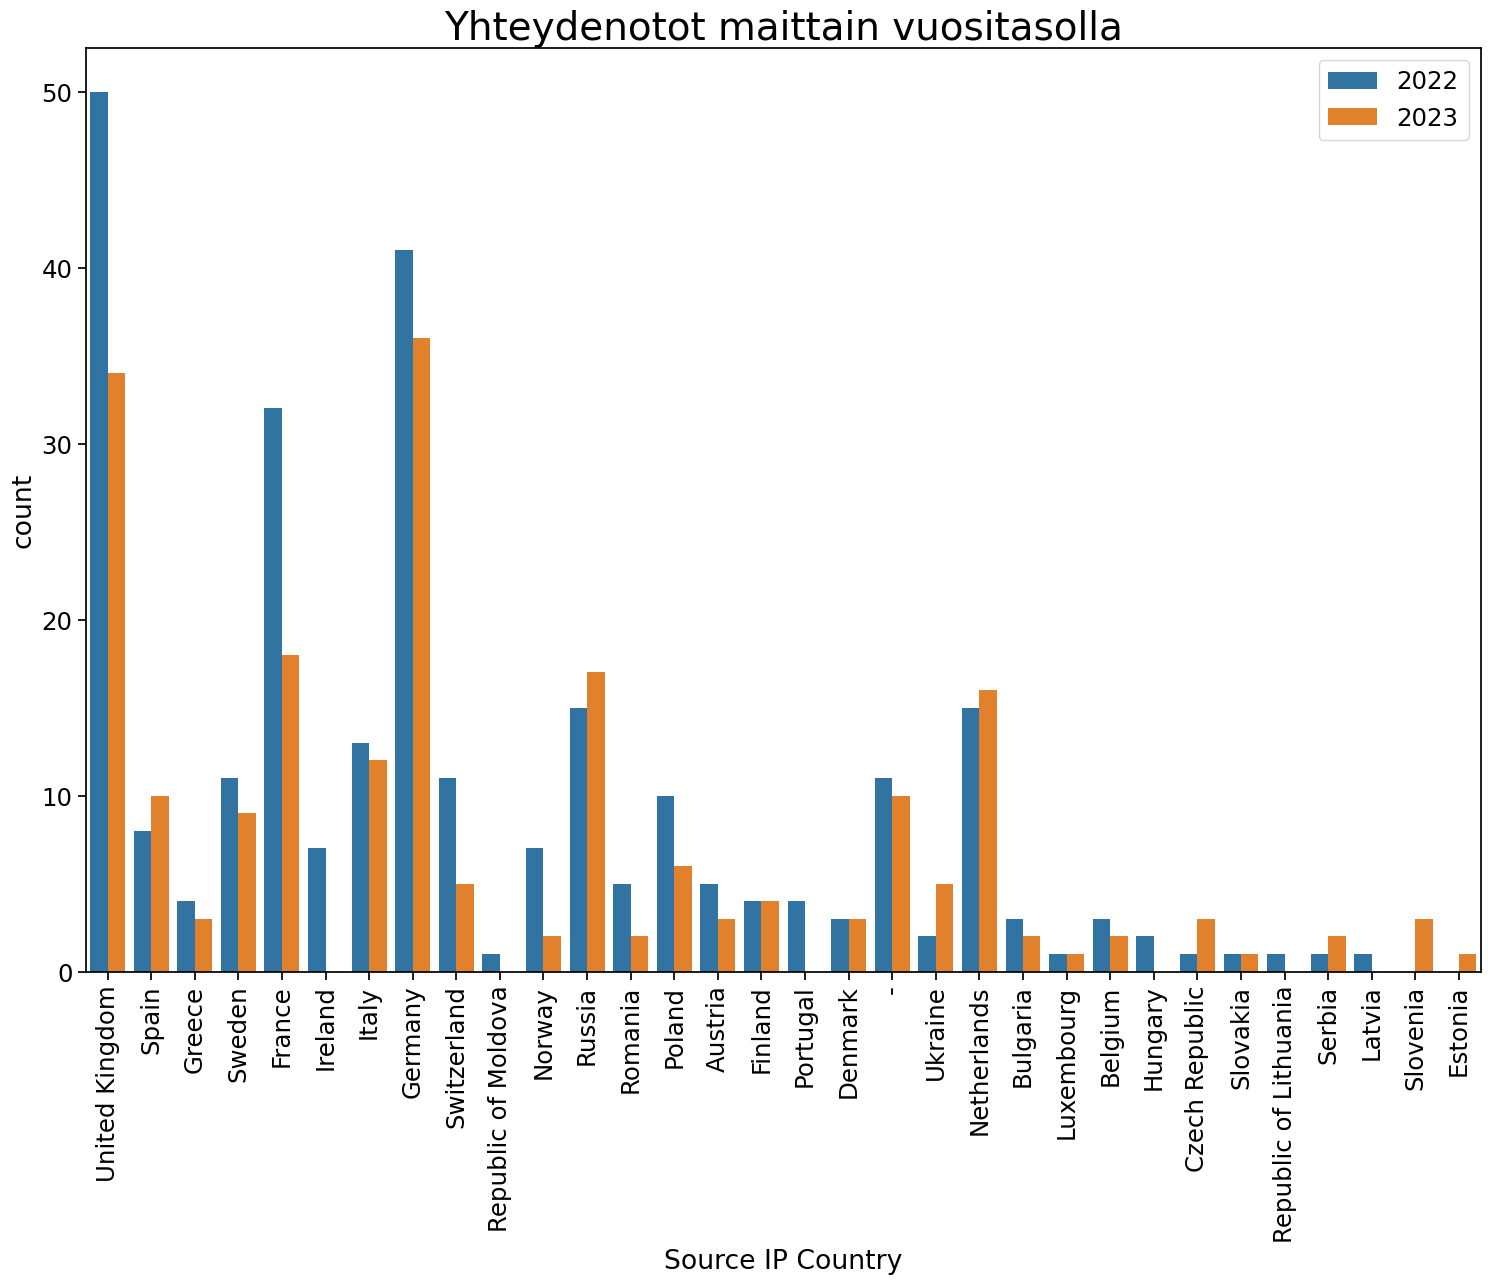

In [200]:
# Data to be used in the chart:
df = pd.read_csv('https://student.labranet.jamk.fi/~ajota/Datasets/cybersecurity_attacks_2022_2023.csv', index_col=0)
df = df.dropna(subset=["Source IP Continent"])
df["Timestamp"] = pd.to_datetime(df["Timestamp"])#conert to timestamp object
df["year"]=df["Timestamp"].dt.year #extract year
df_europe = df[df["Source IP Continent"] == "Europe"] # if source continent is europe
df_europe = df_europe.groupby(["year","Source IP Country"]).size().reset_index(name="count")
df_europe
fig, ax = plt.subplots(figsize=(18, 12))
order=["United Kingdom", "Spain","Greece","Sweden","France","Ireland","Italy","Germany","Switzerland","Republic of Moldova","Norway","Russia","Romania","Poland","Austria","Finland","Portugal","Denmark","-","Ukraine","Netherlands","Bulgaria","Luxembourg","Belgium","Hungary","Czech Republic","Slovakia","Republic of Lithuania","Serbia","Latvia","Slovenia","Estonia"]
sns.barplot(
    data=df_europe,
    x="Source IP Country",
    y="count",
    hue="year",
    palette="tab10",
    order=order
)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
ax.set_title("Yhteydenotot maittain vuositasolla",fontsize=28)
ax.legend(title=None)
plt.xticks(rotation=90)
plt.show()
# Write the code below...